### Which machine learning model to choose?
-   My initial plan was to choose a transformer based approach because from my EE417 (computer vision) experience, transformers can handle long sequence tasks much better than other alternatives like LSTM (RNN). However, I looked at other approaches as my dataset may not be able to leverage the full capabilities of a transformer-based solution due to its size.
-   Possible solutions:

| Model | LSTM (RNN) | Transformer | XGBoost (Gradient Boosted Regression Trees) |
| :--- | :--- | :--- | :--- |
| **Pros** | • Smaller footprint <br> • Good at capturing patterns | • Self-attention has much longer memory <br> • Supports a large variety of data | • Extremely Fast <br> • Handles binary indicator of important changes in the dataset well |
| **Cons** | • Sequential processing makes it easy to forget earlier data <br> • Can't handle binary indicators very well  | • Slow and quadratic memory usage  | • Doesn't have memory |

- At first, I decided on Temporal Fusion Transformers which actually uses LSTM layers for capturing local sequential context and then uses multi-head attention layer for more global context. However, training took a lot of time so I didn't have the time to tune the hyperparameters so I switched back to lstms.
- At first LSTM also caused issues, the predictions were way off (around %30-%60).Then I noticed that when applying scaling to the values to prepare the data, I was applying a single scalar to all the values but the magnitude of the values were different, gold prices were at the 1000$ mark while other items could be easily down to 10-50$ so my solution was to scale them individually and store their scales in a pickle file to load them during inference.

### Preprocessing data before training

- Filling missing data
    - Missing data was due to no trades happening.
    - To fill the data, it makes sense to use the last price available with 0 volume since no trades happened.
    - ~~Adding an indicator called is_synth to let the model know that it is synthetic data.~~ (it is there but not feeded to the model)

- Merging all the data into a single csv file to make it easier to import.
    - Added item name column to differentiate distinct items

In [1]:
from utils.preprocessData import prepare_tft_dataset

prepare_tft_dataset("data/processed1/","ml/master_data.csv")

Preprocessed Data into a Master File


### Training Loop (Got help from llms in order to write the pytorch model classes)

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import datetime
import pickle

MODEL_PATH = "lstm_time_series.pth"
SCALERS_PATH = "lstm_scalers.pkl"

FILE_PATH = "ml/master_data.csv"
SEQ_LENGTH = 14      # Lookback window
FUTURE_DAYS = 14     # How many days to predict forward
BATCH_SIZE = 64
HIDDEN_DIM = 64
NUM_LAYERS = 2
LEARNING_RATE = 0.01 
EPOCHS = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(f"Loading data from {FILE_PATH}...")
df = pd.read_csv(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# Apply Date Filters 
start_date = pd.to_datetime('2025-11-01')
end_date = pd.to_datetime('2026-04-01')
df = df[(df['date'] > start_date) & (df['date'] <= end_date)].copy()

if len(df) == 0:
    raise ValueError("The dataset is empty after applying the date filter.")


df = df.sort_values(by=['item_id', 'date'])

feature_cols = ['price', 'volume', 'afterUpdate']

# Dictionary to store unique scalers 
item_scalers = {}
scaled_dfs = []

# Scale each item individually
for item_id, group in df.groupby('item_id'):
    scaler = MinMaxScaler()
    group_copy = group.copy()
    
    # Fit and transform ONLY on this specific item
    group_copy[feature_cols] = scaler.fit_transform(group_copy[feature_cols])
    
    item_scalers[item_id] = scaler
    scaled_dfs.append(group_copy)

df_scaled = pd.concat(scaled_dfs).sort_values(by=['item_id', 'date'])


def create_sequences_direct(data, seq_length, future_days, feature_cols):
    xs, ys = [], []
    for item_id, group in data.groupby('item_id'):
        group_data = group[feature_cols].values
        
        for i in range(len(group_data) - seq_length - future_days + 1):
            x = group_data[i : (i + seq_length)]
            y = group_data[i + seq_length : i + seq_length + future_days, 0:2] 
            xs.append(x)
            ys.append(y)
            
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X, y = create_sequences_direct(df_scaled, SEQ_LENGTH, FUTURE_DAYS, feature_cols)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

dataset = TimeSeriesDataset(X, y)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


class DirectMultiStepLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, future_days, target_dim):
        super(DirectMultiStepLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.future_days = future_days
        self.target_dim = target_dim
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        # Outputs a flat vector of size: future_days * target_dim (14 * 2 = 28)
        self.fc = nn.Linear(hidden_dim, future_days * target_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :]) 
        
        # Reshape to (batch_size, 14, 2)
        out = out.view(-1, self.future_days, self.target_dim)
        return out

INPUT_DIM = len(feature_cols)
TARGET_DIM = 2

model = DirectMultiStepLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, FUTURE_DAYS, TARGET_DIM).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train():
    print("\nStarting training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
    
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
        
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
            epoch_loss += loss.item()
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss / len(dataloader):.6f}')
        
    print("Training complete!")
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Model weights saved to {MODEL_PATH}")

    with open(SCALERS_PATH, 'wb') as f:
        pickle.dump(item_scalers, f)
    print(f"Scalers saved to {SCALERS_PATH}")


Using device: cuda
Loading data from ml/master_data.csv...

Starting training...
Epoch [1/50], Loss: 0.035079
Epoch [10/50], Loss: 0.014627
Epoch [20/50], Loss: 0.013994
Epoch [30/50], Loss: 0.012109
Epoch [40/50], Loss: 0.010310
Epoch [50/50], Loss: 0.008425
Training complete!
Model weights saved to lstm_time_series.pth
Scalers saved to lstm_scalers.pkl


### Inference Code + Plots

Model loaded successfully.
Scalers loaded successfully.
GOLDS: 


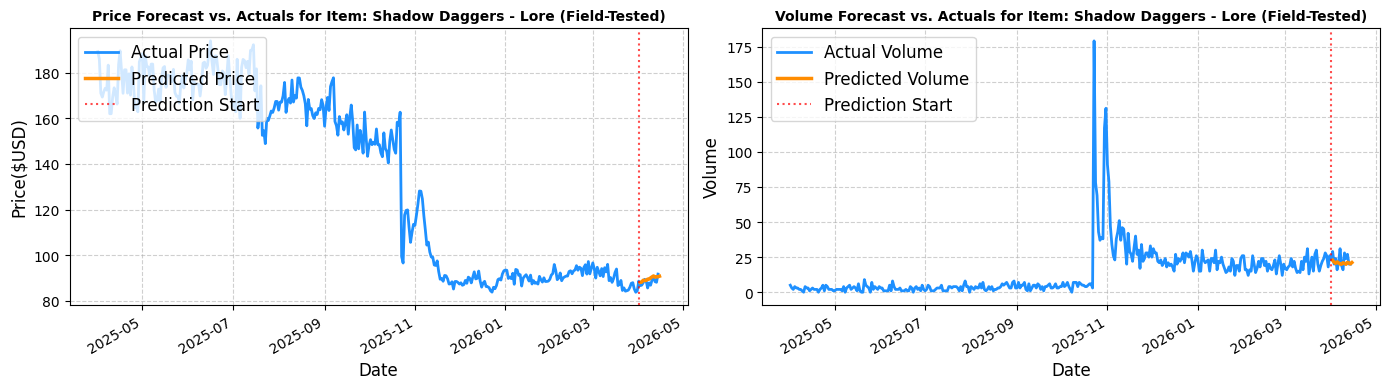

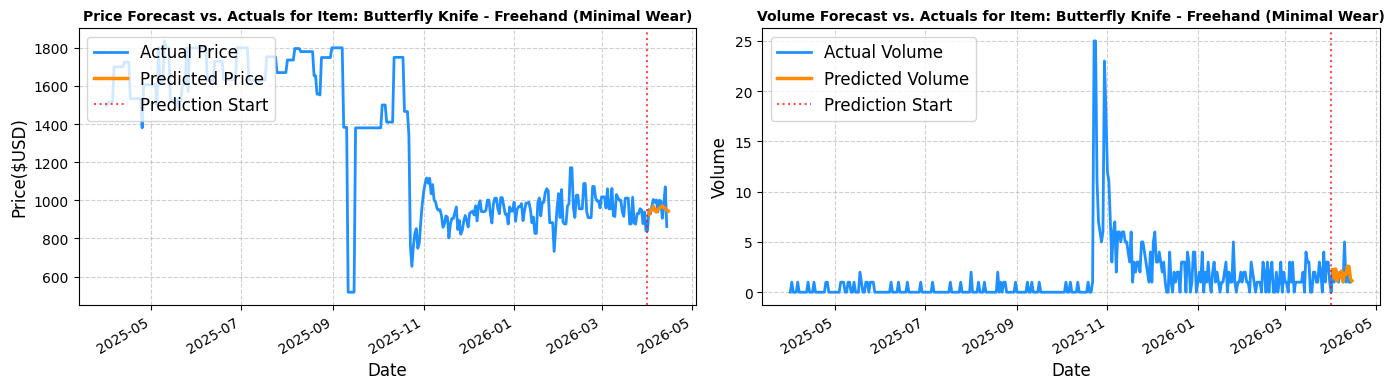

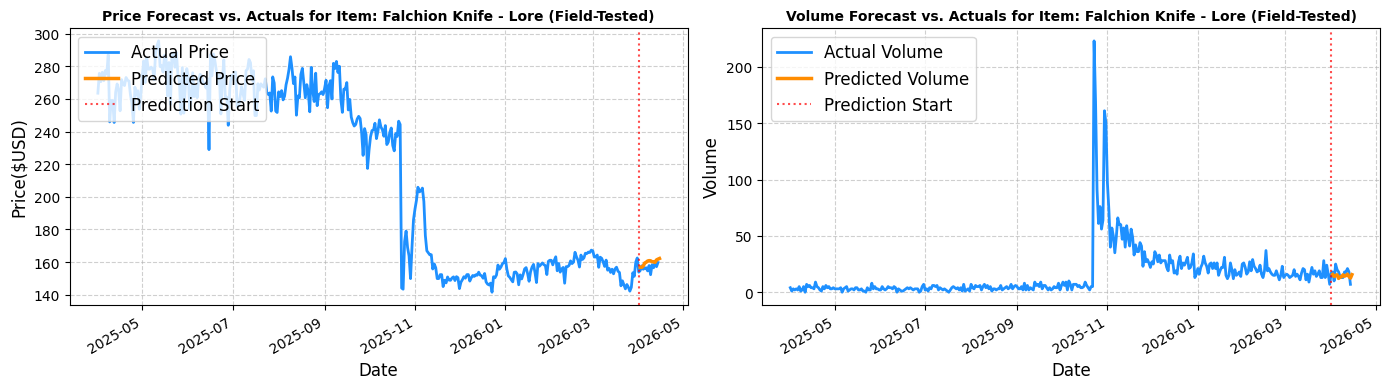

COVERTS: 


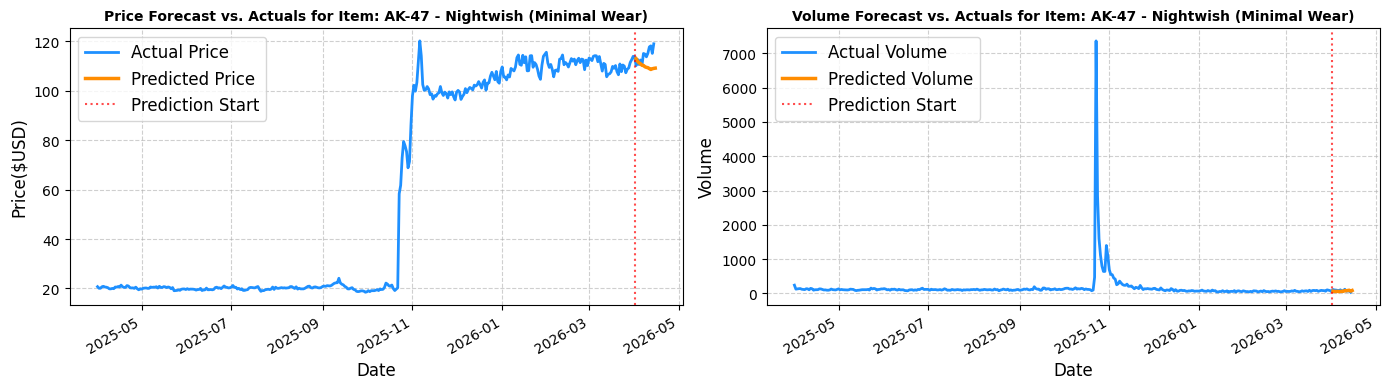

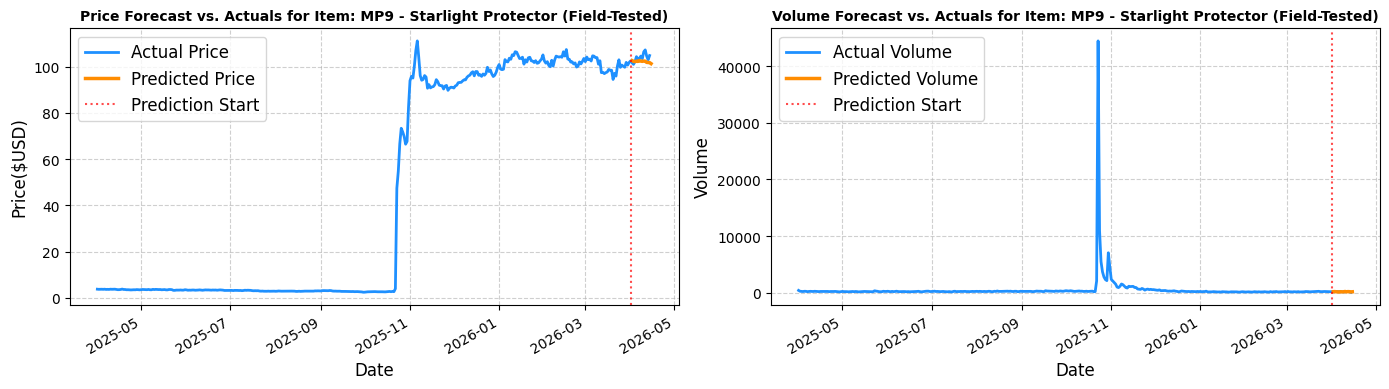

CLASSIFIED: 


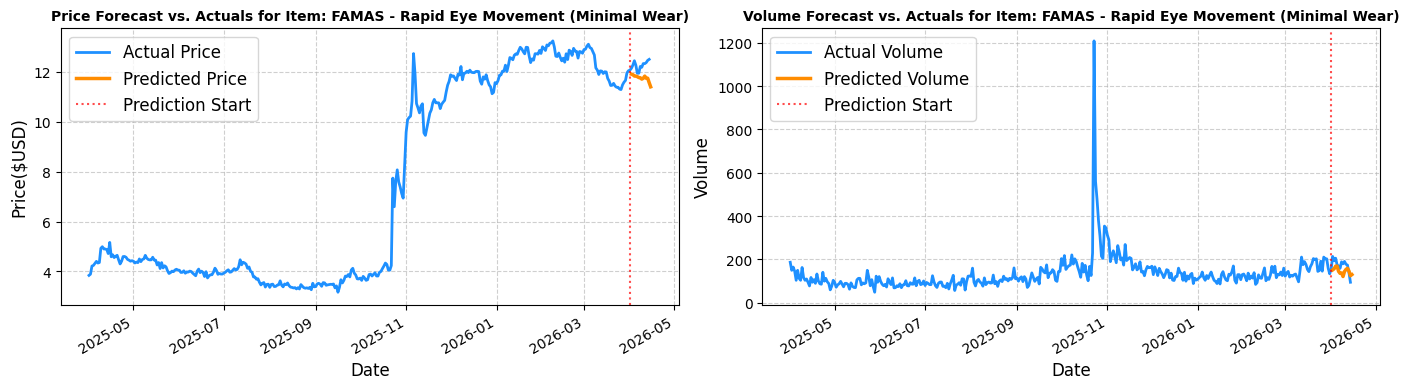

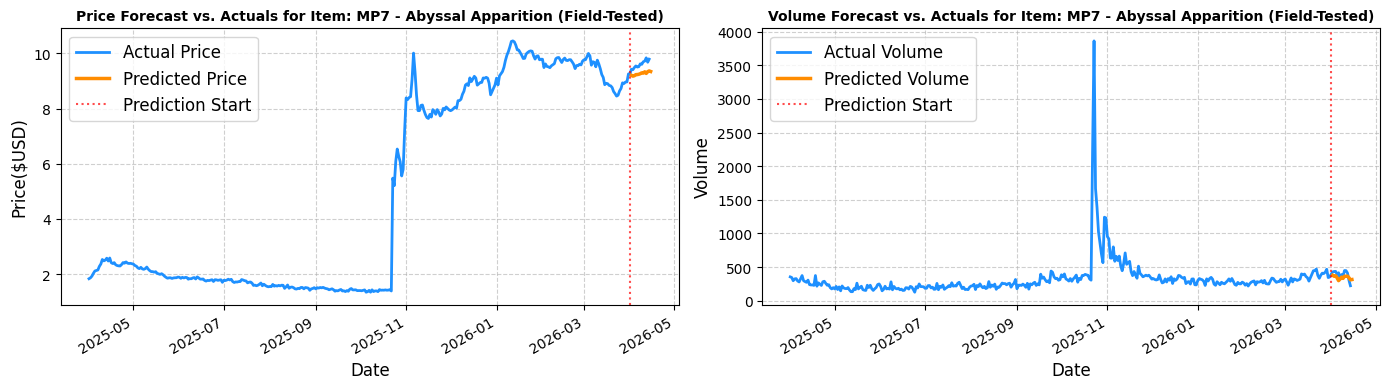

In [111]:
import torch
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
FILE_PATH = "ml/master_data.csv"
MODEL_PATH = "lstm_time_series.pth"
SCALERS_PATH = "lstm_scalers.pkl"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class DirectMultiStepLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, future_days, target_dim):
        super(DirectMultiStepLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.future_days = future_days
        self.target_dim = target_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, future_days * target_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :]) 
        out = out.view(-1, self.future_days, self.target_dim)
        return out


INPUT_DIM = 3
HIDDEN_DIM = 64
NUM_LAYERS = 2
FUTURE_DAYS = 14
TARGET_DIM = 2

loaded_model = DirectMultiStepLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, FUTURE_DAYS, TARGET_DIM).to(device)

loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
loaded_model.eval() # CRITICAL: Set to evaluation mode to disable dropout!
print("Model loaded successfully.")


with open(SCALERS_PATH, 'rb') as f:
    loaded_scalers = pickle.load(f)
print("Scalers loaded successfully.")

def predict_future(model, df_scaled, item_scalers, item_id, feature_cols, seq_length=14, future_days=14):
    model.eval()
    
    item_scaled = df_scaled[df_scaled['item_id'] == item_id].sort_values(by='date')
    if len(item_scaled) < seq_length:
        raise ValueError(f"Need at least {seq_length} days to predict.")
        
    last_sequence = item_scaled[feature_cols].tail(seq_length).values
    current_seq = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred = model(current_seq)
    pred_numpy = pred.cpu().numpy()[0] 
    
    specific_scaler = item_scalers[item_id]
    dummy_col = np.zeros((future_days, 1))
    

    pred_padded = np.hstack((pred_numpy, dummy_col)) 
    

    pred_unscaled = specific_scaler.inverse_transform(pred_padded)[:, 0:2]
    
    last_date = item_scaled['date'].iloc[-1]
    future_dates = [last_date + datetime.timedelta(days=i) for i in range(1, future_days + 1)]
    
    results_df = pd.DataFrame({
        'date': future_dates,
        'item_id': item_id,
        'predicted_price': pred_unscaled[:, 0],
        'predicted_volume': pred_unscaled[:, 1]
    })
    
    return results_df

def plot_pred(item_name):
    forecast_df = predict_future(
        model=loaded_model, 
        df_scaled=df_scaled, 
        item_scalers=loaded_scalers, 
        item_id=item_name, 
        feature_cols=['price', 'volume', 'afterUpdate'],
        seq_length=14,
        future_days=14
    )
    df_original = pd.read_csv(FILE_PATH)
    df_original['date'] = pd.to_datetime(df_original['date'])
    actual_df = df_original[
        (df_original['item_id'] == item_name) & 
        (df_original['date'] >= '2025-04-01') & 
        (df_original['date'] <= '2026-04-14')
    ].copy()
    plt.figure(figsize=(14, 4))
    plt.subplot(1,2,1)
    plt.plot(
        actual_df['date'], 
        actual_df['price'], 
        label='Actual Price', 
        color='dodgerblue', 
        linewidth=2
    )
    plt.plot(
        forecast_df['date'], 
        forecast_df['predicted_price'], 
        label='Predicted Price', 
        color='darkorange', 
        linewidth=2.5
    )
    plt.title(f'Price Forecast vs. Actuals for Item: {item_name}', fontsize=10, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price($USD)', fontsize=12)

    prediction_start_date = pd.to_datetime('2026-04-01')
    plt.axvline(x=prediction_start_date, color='red', linestyle=':', alpha=0.7, label='Prediction Start')

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12, loc='upper left')
    plt.subplot(1,2,2)
    plt.plot(
        actual_df['date'], 
        actual_df['volume'], 
        label='Actual Volume', 
        color='dodgerblue', 
        linewidth=2
    )


    plt.plot(
        forecast_df['date'], 
        forecast_df['predicted_volume'], 
        label='Predicted Volume', 
        color='darkorange', 
        linewidth=2.5
    )
    
    plt.title(f'Volume Forecast vs. Actuals for Item: {item_name}', fontsize=10, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Volume', fontsize=12)

    prediction_start_date = pd.to_datetime('2026-04-01')
    plt.axvline(x=prediction_start_date, color='red', linestyle=':', alpha=0.7, label='Prediction Start')

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12, loc='upper left')
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

print("GOLDS: ")
plot_pred("Shadow Daggers - Lore (Field-Tested)")
plot_pred("Butterfly Knife - Freehand (Minimal Wear)")
plot_pred("Falchion Knife - Lore (Field-Tested)")
print("COVERTS: ")
plot_pred("AK-47 - Nightwish (Minimal Wear)")
plot_pred("MP9 - Starlight Protector (Field-Tested)")
print("CLASSIFIED: ")
plot_pred("FAMAS - Rapid Eye Movement (Minimal Wear)")
plot_pred("MP7 - Abyssal Apparition (Field-Tested)")

### Results

- This LSTM model uses the last 14 days to predict the next 14 days. The model actually doesn't see the data after april 1st. In these graphs the model's prediction of the data after April 1 is compared to the actual data at those time intervals. When I used larger lookback windows, the predictions got further away from the actual results. This shows that the market is very volatile and its dynamics also change a lot.
- The model had a bit of issue predicting the lower class items, however it did a good job of predicting the prices of golds. This could be due to the fact that gold prices are affected by the lower class items so as we approach gold rarity class we have more data that can support the prices of golds.
- The predictions of given gold class items show that golds are in an increasing trend which supports the claims in my proposal.
- Volume predictions are mostly good on all classes.